# Practica 2: Procesamiento de datasets

César Eduardo Jardines Mendoza
Cuatrimestre III-2026
CICESE

### Descripción del contexto y procedencia del dataset

Para esta práctica se utilizó un dataset extraído del sitio del [Instituto Nacional de Estadística y Geografía (INEGI)](https://www.inegi.org.mx/programas/enape/2021/default.html#microdatos) el cual consta de una estructura de datos organizados que escogí de una Encuesta Nacional sobre Acceso y Permanencia en la Educación (ENAPE) 2021. El objetivo de la encuesta fue generar información estadística sobre las características educativas de la población de 0 a 29 años en México, con especial atención en el grupo de 3 a 29 años.

## Periodo que contempla

- **Levantamiento:** noviembre de 2021, por vía telefónica, debido a la situación de COVID-19.
- **Ciclos escolares de referencia:**
  - **2020-2021**
  - **2021-2022**

## Estructura de los datos

Se distribuyen en **dos tablas** con una relación de uno a muchos:

| Tabla | Unidad de observación | Llave | Núm. de variables |
|---|---|---|---|
| `tvivienda` | Vivienda | `folio` | 17 |
| `tmodulo` | Persona de 0 a 29 años | `folio` + `n_ren` | 101 |

Una vivienda puede tener varias personas registradas en `tmodulo`, con `n_ren` del 01 al 13. Las tablas se unen mediante `folio`.

Los datos son de acceso público y gratuito de acuerdo a los [Términos de Libre Uso de la Información del INEGI](https://www.inegi.org.mx/inegi/terminos.html).

Al revisar el diccionario de datos y la estructura del cuestionario, se observó que no todas las personas responden las mismas preguntas de la tabla `tmodulo`. Por ejemplo, quienes están inscritos en el ciclo escolar 2021-2022 responden la mayor parte del apartado B, mientras que quienes no están inscritos contestan preguntas específicas, como `pb3_2`. Esto determina identificar que la pregunta `pb3_1` con respecto al diccionario de datos, la pregunta **¿Está inscrita(o) en el actual ciclo escolar 2021-2022?** es la que determina qué preguntas debe responder cada persona.

Es por eso que se decidió utilizar `pb3_1` como nuestra variable objetivo para el uso de algunas técnicas.



## Verificación de la estructura, análisis y limpieza de datos



In [32]:
import pandas as pd

# Cargamos los archivos
ruta_mod = "conjunto_de_datos_tmodulo_enape_2021.csv"
ruta_viv = "conjunto_de_datos_tvivienda_enape_2021.csv"

mod = pd.read_csv(ruta_mod, dtype=str, encoding="utf-8-sig")
viv = pd.read_csv(ruta_viv, dtype=str, encoding="utf-8-sig")
print(f"Tamaño: ",mod.shape, viv.shape)

print(mod["PB3_1"].value_counts(normalize=True, dropna=False).round(3) * 100)
print("PB3_2 respondida según PB3_1:")
print(mod.groupby("PB3_1", dropna=False)["PB3_2"].apply(lambda s: s.notna().mean()).round(3))
cobertura = mod.filter(regex="^P[BC]3_").notna().mean().round(3) * 100
print(f"Columnas: ",cobertura.sort_values())

# Confirmamos de donde viene 6.4 porciento de vacíos en PB3_1
mod["EDAD_NUM"] = mod["EDAD"].astype(int)
print(mod.loc[mod["PB3_1"].isna(), "EDAD_NUM"].value_counts().sort_index())

# Obtenemos los registros de la población arriba de 3 años
df = mod[mod["EDAD_NUM"] >= 3].copy()
print(df.shape)
print(df["PB3_1"].value_counts(normalize=True, dropna=False).round(3) * 100)


Tamaño:  (32343, 101) (22719, 17)
PB3_1
1      60.8
2      32.9
NaN     6.4
Name: proportion, dtype: float64
PB3_2 respondida según PB3_1:
PB3_1
1      0.0
2      1.0
NaN    0.0
Name: PB3_2, dtype: float64
Columnas:  PB3_5_TRIMESTRE        0.1
PB3_5_BIMESTRE         0.1
PB3_5_MODMAT           0.1
PB3_4                  1.0
PB3_5_CUATRIMESTRE     1.0
PC3_2                  2.5
PC3_8                  9.8
PB3_5_SEMESTRE        12.4
PC3_3_2               25.0
PC3_5                 25.0
PC3_4                 25.0
PC3_6                 25.0
PC3_3_1               25.0
PC3_1                 27.5
PC3_7                 30.4
PB3_2                 32.9
PB3_7                 36.3
PB3_14                38.0
PB3_8                 44.9
PB3_5_ANIO            47.0
PB3_13_1              47.9
PB3_13_3              47.9
PB3_13_7              47.9
PB3_13_5              47.9
PB3_13_4              47.9
PB3_13_6              47.9
PB3_15                47.9
PB3_13_2              47.9
PB3_10_3              60.7


### Definición de la población de análisis

Al explorar los valores vacíos de `PB3_1`, se encontró que el 6.4% de los registros (2,055 personas) no tienen respuesta. Por lo tanto estos datos vacios no representan información perdida, sino preguntas que no aplican.

Entonces tomaremos como la población de análisis a las personas de 3 a 29 años, quedando `30288` registros.

In [33]:
df = df.merge(viv.drop(columns=["ENT", "FACTOR"]), on="FOLIO",
              how="left", validate="many_to_one")
print(df.shape)

(30288, 116)


Las variables del hogar (equipamiento, internet, opinión sobre la educación) están en `viv` y probablemente son igual de importantes.

Ahora tenemos 30,288 filas y 116 columnas. Ahora vamos a ver cómo se ven nuestros datos en este punto.

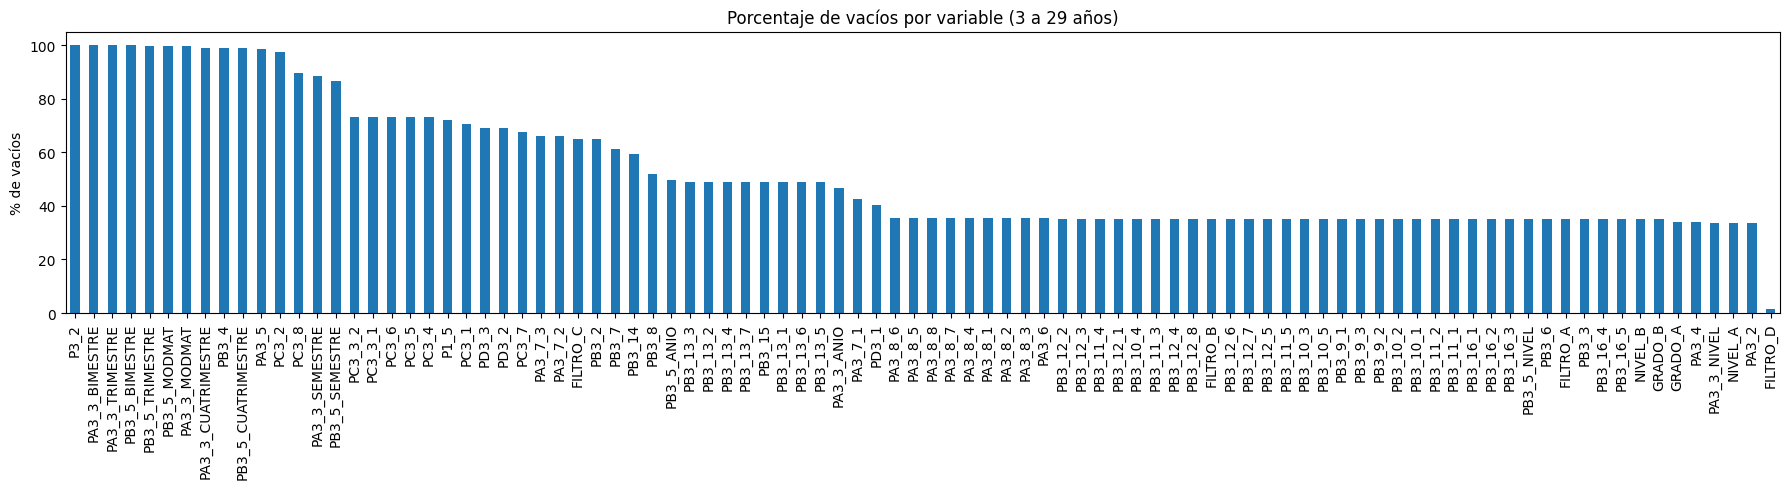

In [34]:
import matplotlib.pyplot as plt
vacios = df.isna().mean().mul(100).sort_values(ascending=False)
vacios[vacios > 0].plot(kind="bar", figsize=(18, 5))
plt.ylabel("% de vacíos"); plt.title("Porcentaje de vacíos por variable (3 a 29 años)")
plt.tight_layout(); plt.show()

Para cada variable la gráfica muestra el porcentaje de registros sin respuesta dentro de la población de análisis, es importante mencionar que se toman en consideración las personas de 3 a 29 años. Las variables que no
aparecen como `SEXO`, `EDAD`, `P3_1`, `ENT` o las de vivienda `P1_1` a `P1_4_*` no tienen vacíos.

Es fácil cuestionarse el porqué de las variables totalmente vacías, como por ejemplo `P3_2`, esa pregunta es ¿(Nombre del encuestado) recibe educación inicial o asiste a la estancia o guardería? Esa pregunta solo se hace a niños de 0 a 2 años y se excluyeron al definir la población por lo que al quedarnos con personas de 3 a 29 años, se eliminó a todos los que la respondían.

La mayoría de los valores faltantes son **estructurales** y corresponden a preguntas que no aplican a cada persona según su edad o su condición de inscripción. En la etapa de
limpieza estos vacíos se tratarán según el caso.



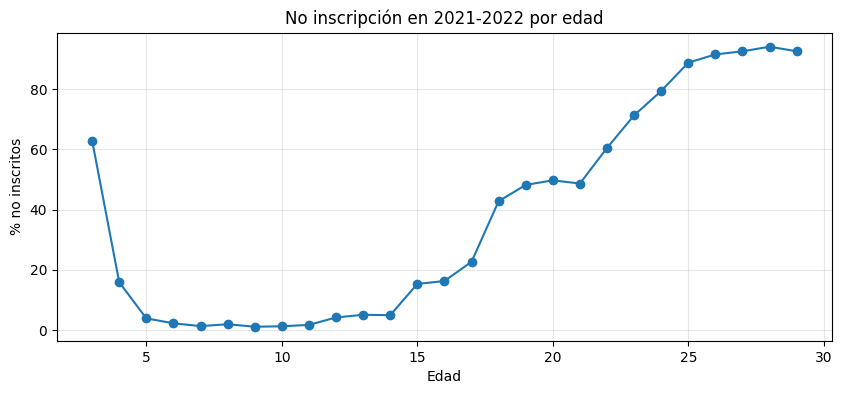

In [35]:
tasa = df.groupby("EDAD_NUM")["PB3_1"].apply(lambda s: (s == "2").mean() * 100)
tasa.plot(marker="o", figsize=(10, 4))
plt.xlabel("Edad"); plt.ylabel("% no inscritos"); plt.title("No inscripción en 2021-2022 por edad")
plt.grid(alpha=.3); plt.show()

Obtenemos una gráfica que muestra los datos de clase "no inscrito". La proporción de personas no inscritas en el ciclo 2021-2022 no es uniforme entre edades.

Para que la variable objetivo tenga una interpretación consistente, se acotó la población de análisis a personas de **6 a 17 años**, rango que corresponde a la edad típica de cursar primaria, secundaria y preparatoria. En este rango, no estar inscrito representa una interrupción de la trayectoria escolar y no la conclusión de los estudios.

In [36]:
df = df[df["EDAD_NUM"].between(6, 17)].copy()
print(df.shape, df["EDAD_NUM"].min(), df["EDAD_NUM"].max())
print(df["PB3_1"].value_counts(normalize=True).round(3) * 100)

(14350, 116) 6 17
PB3_1
1    93.4
2     6.6
Name: proportion, dtype: float64


In [37]:
for col in ["SEXO", "P1_4_6", "P1_4_2", "PA3_2", "PA3_4"]:
    print(pd.crosstab(df[col], df["PB3_1"], normalize="index").round(3) * 100, "\n")

PB3_1     1    2
SEXO            
1      92.5  7.5
2      94.3  5.7 

PB3_1      1     2
P1_4_6            
1       95.7   4.3
2       88.1  11.9 

PB3_1      1    2
P1_4_2           
1       97.2  2.8
2       90.9  9.1 

PB3_1     1    2
PA3_2           
1      96.3  3.7
2      98.2  1.8 

PB3_1     1     2
PA3_4            
1      97.2   2.8
2      41.8  58.2 



Cada tabla muestra, para cada valor de la variable, cuál fue el porcentaje que se inscribió (columna 1) y qué porcentaje no (columna 2).

### Relación de la variable objetivo con otras variables

Con la población acotada a 6 a 17 años (14,350 registros), el 6.6% de las personas no estaba inscrita en el ciclo 2021-2022, lo que representa un desbalance marcado
entre clases.

Las tablas cruzadas muestran que:

- **Sexo:** la diferencia en la no inscripción es leve (7.5% frente a 5.7%).
- **Equipamiento del hogar:** en las viviendas sin internet fijo, la no inscripción
  es de 11.9%, frente a 4.3% en las que sí tienen. Un patrón similar se observa con
  la disponibilidad de laptop (9.1% frente a 2.8%).
- **Conclusión del ciclo anterior:** es la relación entre
  quienes no concluyeron su grado en 2020-2021, el 58.2% no se inscribió en el ciclo siguiente, frente a 2.8% de quienes sí lo concluyeron.
- **Tipo de escuela y conclusión del ciclo anterior** solo están disponibles para quienes estuvieron inscritos en 2020-2021, por lo que sus resultados describen a ese subgrupo.

Estos resultados muestran que las variables de trayectoria escolar previa y de equipamiento del hogar son candidatas relevantes para las etapas de extracción y selección de características.

In [38]:
print("Duplicados por persona:", df.duplicated(subset=["FOLIO", "N_REN"]).sum())
print("Filas idénticas:", df.duplicated().sum())

Duplicados por persona: 0
Filas idénticas: 0


Confirmamos que no hay personas repetidas ni filas idénticas.

In [39]:
vacios = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
print(vacios[vacios > 0].to_string())

PA3_3_BIMESTRE        100.0
PA3_3_TRIMESTRE       100.0
PA3_3_CUATRIMESTRE    100.0
P3_2                  100.0
PA3_3_MODMAT          100.0
PB3_5_MODMAT          100.0
PB3_5_TRIMESTRE       100.0
PB3_5_BIMESTRE        100.0
PB3_5_CUATRIMESTRE     99.9
PC3_2                  99.6
PB3_4                  98.8
PA3_5                  98.7
PC3_3_2                97.1
PC3_4                  97.1
PC3_5                  97.1
PC3_6                  97.1
PC3_3_1                97.1
PC3_8                  96.8
PC3_1                  96.7
PC3_7                  93.7
FILTRO_C               93.4
PB3_2                  93.4
PA3_3_SEMESTRE         93.0
PD3_2                  93.0
PD3_3                  93.0
PB3_5_SEMESTRE         88.4
P1_5                   69.4
PD3_1                  65.2
PA3_7_3                62.2
PA3_7_2                62.2
PB3_7                  39.3
PB3_8                  33.8
PB3_14                 28.8
PB3_5_ANIO             18.4
PA3_7_1                12.5
PA3_3_ANIO          

In [40]:
presencia = df.drop(columns="PB3_1").notna().groupby(df["PB3_1"]).mean().T.mul(100).round(1)
presencia.columns = ["inscritos", "no_inscritos"]
presencia["diferencia"] = (presencia["inscritos"] - presencia["no_inscritos"]).abs()
print(presencia[(presencia["diferencia"] > 1) & (presencia["diferencia"] < 99)].sort_values("diferencia", ascending=False).to_string())

                inscritos  no_inscritos  diferencia
PC3_7                 0.0          94.5        94.5
PB3_5_ANIO           87.4           0.0        87.4
PB3_14               76.3           0.0        76.3
PB3_8                70.9           0.0        70.9
PB3_7                65.1           0.0        65.1
PA3_8_4              98.0          39.2        58.8
PA3_6                98.0          39.2        58.8
PA3_8_7              98.0          39.2        58.8
PA3_8_8              98.0          39.2        58.8
PA3_8_6              98.0          39.2        58.8
PA3_8_2              98.0          39.2        58.8
PA3_8_3              98.0          39.2        58.8
PA3_8_1              98.0          39.2        58.8
PA3_8_5              98.0          39.2        58.8
PA3_7_1              91.0          38.5        52.5
PC3_1                 0.0          49.6        49.6
PA3_3_NIVEL          98.6          50.4        48.2
GRADO_A              98.6          50.4        48.2
PA3_4       

In [41]:
print(pd.crosstab(df["ESC"], df["PB3_1"], normalize="columns").round(3) * 100)

PB3_1     1     2
ESC              
0       0.4   5.5
1       7.2   2.5
2      53.1  26.9
3      27.2  53.6
4      12.2  11.5


Confirmamos que la clase `ESC` (escolaridad alcanzada) no aparece en la tabla porque su presencia es igual en ambos grupos, pero su contenido podría derivarse de NIVEL_B en los inscritos y de PC3_3 en los no inscritos.

In [42]:
sin_info = ["P3_2", "PA3_3_BIMESTRE", "PA3_3_TRIMESTRE", "PA3_3_CUATRIMESTRE", "PA3_3_MODMAT", "PA3_5"]
redundantes = ["PA3_3_NIVEL", "PA3_3_SEMESTRE", "PA3_3_ANIO", "EDAD"]
fuga = [c for c in df.columns if (c.startswith("PB3_") and c != "PB3_1")
        or c.startswith("PC3_") or c.startswith("PD3_")]
fuga += ["FILTRO_A", "FILTRO_B", "FILTRO_C", "FILTRO_D", "NIVEL_B", "GRADO_B"]

df_limpio = df.drop(columns=sin_info + redundantes + fuga)
print("Antes:", df.shape, "| Después:", df_limpio.shape)
print(len(sin_info), "sin información,", len(redundantes), "redundantes,", len(fuga), "con fuga")

Antes: (14350, 116) | Después: (14350, 40)
6 sin información, 4 redundantes, 66 con fuga


Se decidió eliminar algunas variables de nuestro análisis por tres razones principales:

1. **Variables sin información:** eliminamos aquellas que no tenían datos para las personas de entre 6 y 17 años. Por ejemplo, `P3_2`, que únicamente aplica a menores de 3 años, así como algunas variables relacionadas con grados escolares que no se utilizaron. También descartamos variables como `PA3_5`, porque tenían más del 98% de sus datos vacíos.

2. **Variables con información repetida:** encontramos variables que contenían información que ya podíamos obtener de otras. Por ejemplo, los datos sobre el grado escolar del ciclo anterior ya estaban resumidos en `NIVEL_A` y `GRADO_A`. De igual manera, decidimos utilizar `EDAD_NUM` en lugar de `EDAD`, ya que contiene la edad en formato numérico.

3. **Variables que podían revelar la respuesta:** comparamos qué tantos datos tenía cada variable entre las personas inscritas y las no inscritas. Así identificamos algunas preguntas que solo se responden dependiendo de si la persona está inscrita o no, como las de los apartados B y C, las relacionadas con el nivel y grado escolar del ciclo actual y algunas que controlan el flujo del cuestionario. Decidimos quitarlas porque podrían darle al modelo pistas demasiado directas sobre lo que queremos predecir, provocando una *fuga de información*.

También excluimos el apartado D, ya que contiene información sobre las actividades que realiza la persona durante el mismo periodo escolar. Consideramos que algunas de estas actividades podrían ser consecuencia de no estar inscrita y no necesariamente una causa o característica previa que nos ayude a predecir su inscripción.

In [43]:
for nombre in ["pa3_7_1", "grado_a", "p4_1_1", "p1_5"]:
    print(nombre, "\n", pd.read_csv(nombre + ".csv", encoding="utf-8-sig"), "\n")

pa3_7_1 
    cve  descrip
0    1       Sí
1    2       No
2    9  No sabe 

grado_a 
      cve          descrip
0  1...6            Grado
1      9  No especificado 

p4_1_1 
    cve          descrip
0    1   Muy de acuerdo
1    2  Algo de acuerdo
2    3  Poco de acuerdo
3    4  Nada de acuerdo
4    9          No sabe 

p1_5 
    cve                                            descrip
0    1                   Por falta de recursos económicos
1    2                   No le interesa o no lo necesitan
2    3                                     No sabe usarlo
3    4                             Desconocen su utilidad
4    5                  Equipo inadecuado o sin capacidad
5    6  No hay servicio en su localidad (falta de infr...
6    7           Tiene acceso a internet en otros lugares
7    8  Por razones relacionadas con la privacidad o s...
8    9                                         Otra razón
9   99                                        No responde 



In [44]:
for c in ["PA3_7_1", "PA3_7_2", "PA3_7_3", "P4_1_1", "P4_1_2", "P4_1_3", "GRADO_A", "P1_5"]:
    print(c, df_limpio[c].value_counts(dropna=False).sort_index().to_dict())

PA3_7_1 {'1': 1419, '2': 10972, '9': 163, nan: 1796}
PA3_7_2 {'1': 442, '2': 4876, '9': 110, nan: 8922}
PA3_7_3 {'1': 176, '2': 5141, '9': 111, nan: 8922}
P4_1_1 {'1': 10967, '2': 2581, '3': 633, '4': 146, '9': 23}
P4_1_2 {'1': 10365, '2': 3095, '3': 766, '4': 109, '9': 15}
P4_1_3 {'1': 8478, '2': 3828, '3': 1525, '4': 475, '9': 44}
GRADO_A {'1': 3297, '2': 3181, '3': 3559, '4': 1173, '5': 1168, '6': 1303, '9': 3, nan: 666}
P1_5 {'01': 3446, '02': 217, '03': 16, '04': 3, '05': 39, '06': 471, '07': 106, '08': 11, '09': 80, '99': 6, nan: 9955}


Se consultaron los catálogos del INEGI para identificar los códigos que no representan respuestas sustantivas. Los códigos "No sabe" (9 en `PA3_7_*` y `P4_1_*`), "No especificado" (9 en `GRADO_A`) y "No responde" (99 en `P1_5`) se convirtieron en valores faltantes. En `P1_5`, el código 9 corresponde a "Otra razón", una respuesta válida, por lo que se conservó.

In [45]:
codigos_especiales = {
    "PA3_7_1": ["9"], "PA3_7_2": ["9"], "PA3_7_3": ["9"],
    "P4_1_1": ["9"], "P4_1_2": ["9"], "P4_1_3": ["9"],
    "GRADO_A": ["9"],
    "P1_5": ["99"],
}
for col, codigos in codigos_especiales.items():
    antes = df_limpio[col].isin(codigos).sum()
    df_limpio[col] = df_limpio[col].replace(codigos, pd.NA)
    print(f"{col}: {antes} valores convertidos a NaN")

PA3_7_1: 163 valores convertidos a NaN
PA3_7_2: 110 valores convertidos a NaN
PA3_7_3: 111 valores convertidos a NaN
P4_1_1: 23 valores convertidos a NaN
P4_1_2: 15 valores convertidos a NaN
P4_1_3: 44 valores convertidos a NaN
GRADO_A: 3 valores convertidos a NaN
P1_5: 6 valores convertidos a NaN


In [46]:
print(df_limpio.columns.tolist())
print(df_limpio.isna().sum()[df_limpio.isna().sum() > 0])

['FOLIO', 'N_REN', 'SEXO', 'P3_1', 'PA3_1', 'PA3_2', 'PA3_4', 'PA3_6', 'PA3_7_1', 'PA3_7_2', 'PA3_7_3', 'PA3_8_1', 'PA3_8_2', 'PA3_8_3', 'PA3_8_4', 'PA3_8_5', 'PA3_8_6', 'PA3_8_7', 'PA3_8_8', 'PB3_1', 'ENT', 'NIVEL_A', 'GRADO_A', 'ESC', 'FACTOR', 'EDAD_NUM', 'P1_1', 'P1_2_1', 'P1_2_2', 'P1_3', 'P1_4_1', 'P1_4_2', 'P1_4_3', 'P1_4_4', 'P1_4_5', 'P1_4_6', 'P1_5', 'P4_1_1', 'P4_1_2', 'P4_1_3']
PA3_2       666
PA3_4       666
PA3_6       850
PA3_7_1    1959
PA3_7_2    9032
PA3_7_3    9033
PA3_8_1     850
PA3_8_2     850
PA3_8_3     850
PA3_8_4     850
PA3_8_5     850
PA3_8_6     850
PA3_8_7     850
PA3_8_8     850
NIVEL_A     666
GRADO_A     669
P1_5       9961
P4_1_1       23
P4_1_2       15
P4_1_3       44
dtype: int64


Los vacíos restantes se analizaron cruzándolos con las variables que controlan el
flujo del cuestionario.

In [47]:
sub = df_limpio[df_limpio["PA3_1"] == "1"]
print(pd.crosstab(sub["PA3_4"], sub["PA3_6"].isna()), "\n")
print(pd.crosstab(sub["NIVEL_A"], sub["PA3_7_1"].isna()), "\n")
print(pd.crosstab(sub["NIVEL_A"], sub["PA3_7_2"].isna()))

PA3_6  False  True 
PA3_4              
1      13500      0
2          0    184 

PA3_7_1  False  True 
NIVEL_A              
02           0    954
03        7047    121
04        3578     95
05          25      2
06        1358    104
07         383     17 

PA3_7_2  False  True 
NIVEL_A              
02           0    954
03           0   7168
04        3557    116
05          25      2
06        1355    107
07         381     19


In [48]:
def no_aplica(cols, mask):
    for c in cols:
        df_limpio.loc[mask & df_limpio[c].isna(), c] = "No aplica"

cols_a  = [c for c in df_limpio.columns if c.startswith("PA3_") and c != "PA3_1"] + ["NIVEL_A", "GRADO_A"]
cols_68 = ["PA3_6"] + [c for c in df_limpio.columns if c.startswith("PA3_8_")]
cols_7  = ["PA3_7_1", "PA3_7_2", "PA3_7_3"]

no_aplica(cols_a, df_limpio["PA3_1"] == "2")                          # R1: no inscrito en 2020-2021
no_aplica(cols_68 + cols_7, df_limpio["PA3_4"] == "2")                # R2: no concluyó el grado
no_aplica(["PA3_7_1"], df_limpio["NIVEL_A"] == "02")                  # R3: no aplica en nivel 02
no_aplica(["PA3_7_2", "PA3_7_3"], df_limpio["NIVEL_A"].isin(["02", "03"]))  # R4: no aplica en niveles 02 y 03
no_aplica(["P1_5"], df_limpio["P1_4_6"] == "1")                       # R5: la vivienda tiene internet

residuales = df_limpio.isna().sum()
print(residuales[residuales > 0])

PA3_7_1    163
PA3_7_2    110
PA3_7_3    111
GRADO_A      3
P1_5         6
P4_1_1      23
P4_1_2      15
P4_1_3      44
dtype: int64


Se identificaron cinco reglas que explican su origen:

| Regla | Condición | Variables afectadas |
|---|---|---|
| R1 | No inscrito en 2020-2021 (`PA3_1 = 2`) | Todo el apartado A, `NIVEL_A`, `GRADO_A` |
| R2 | No concluyó el grado (`PA3_4 = 2`) | `PA3_6`, `PA3_7_*`, `PA3_8_*` |
| R3 | Nivel escolar 02 | `PA3_7_1` |
| R4 | Niveles escolares 02 y 03 | `PA3_7_2`, `PA3_7_3` |
| R5 | La vivienda tiene internet fijo | `P1_5` |

In [49]:
especiales = {"PA3_7_1": "9", "PA3_7_2": "9", "PA3_7_3": "9", "GRADO_A": "9",
              "P1_5": "99", "P4_1_1": "9", "P4_1_2": "9", "P4_1_3": "9"}
for c, cod in especiales.items():
    print(f"{c}: códigos originales = {(df[c] == cod).sum()} | residuales = {df_limpio[c].isna().sum()}")

PA3_7_1: códigos originales = 163 | residuales = 163
PA3_7_2: códigos originales = 110 | residuales = 110
PA3_7_3: códigos originales = 111 | residuales = 111
GRADO_A: códigos originales = 3 | residuales = 3
P1_5: códigos originales = 6 | residuales = 6
P4_1_1: códigos originales = 23 | residuales = 23
P4_1_2: códigos originales = 15 | residuales = 15
P4_1_3: códigos originales = 44 | residuales = 44


In [58]:
for c in especiales:
    validos = df_limpio.loc[df_limpio[c] != "No aplica", c]
    moda = validos.mode()[0]
    n = df_limpio[c].isna().sum()
    df_limpio[c] = df_limpio[c].fillna(moda)
    print(f"{c}: {n} valores imputados con la moda ({moda})")

print("Vacíos totales restantes:", df_limpio.isna().sum().sum())

PA3_7_1: 163 valores imputados con la moda (2)
PA3_7_2: 110 valores imputados con la moda (2)
PA3_7_3: 111 valores imputados con la moda (2)
GRADO_A: 3 valores imputados con la moda (3)
P1_5: 6 valores imputados con la moda (01)
P4_1_1: 23 valores imputados con la moda (1)
P4_1_2: 15 valores imputados con la moda (1)
P4_1_3: 44 valores imputados con la moda (1)
Vacíos totales restantes: 0


En estos casos, los datos estaban vacíos porque las preguntas no les correspondían a ciertas personas, así que decidimos identificarlos con la categoría "No aplica", en lugar de intentar completar esa información.

Como siguiente paso vamos a realizar una prueba de inconsistencia. El total de personas debería ser igual a hombres más mujeres.

In [59]:
numericas = ["EDAD_NUM", "P1_1", "P1_2_1", "P1_2_2", "FACTOR"]
ordinales = ["P4_1_1", "P4_1_2", "P4_1_3", "ESC"]
identificadores = ["FOLIO", "N_REN"]
nominales = [c for c in df_limpio.columns
             if c not in numericas + ordinales + identificadores + ["PB3_1"]]

df_limpio[numericas] = df_limpio[numericas].astype(int)
df_limpio[ordinales] = df_limpio[ordinales].astype(int)
df_limpio[nominales] = df_limpio[nominales].astype("category")
df_limpio["NO_INSCRITO"] = (df_limpio["PB3_1"] == "2").astype(int)
df_limpio = df_limpio.drop(columns="PB3_1")

print(df_limpio.dtypes.value_counts())
print(df_limpio["NO_INSCRITO"].value_counts())

category    13
int64       10
category     8
object       2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64
NO_INSCRITO
0    13396
1      954
Name: count, dtype: int64


In [60]:
inconsistentes = df_limpio["P1_1"] != df_limpio["P1_2_1"] + df_limpio["P1_2_2"]
print("Registros inconsistentes:", inconsistentes.sum())

Registros inconsistentes: 0


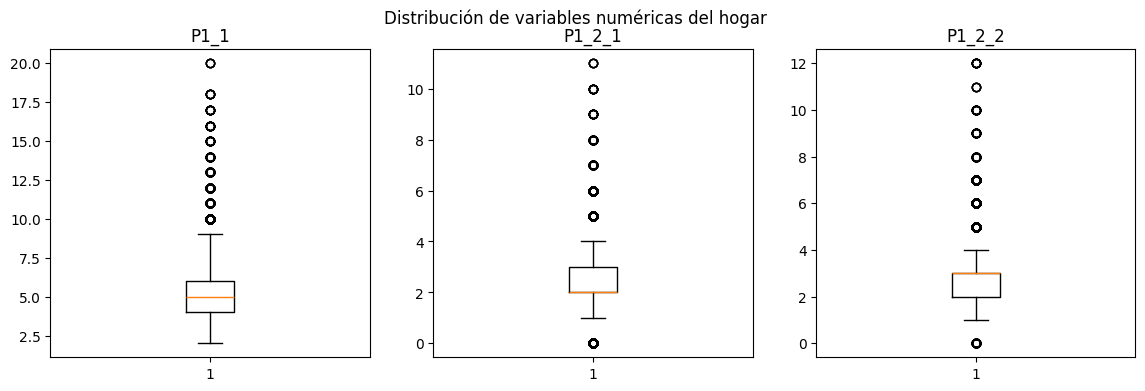

P1_1: límite superior = 9.0, outliers = 563, máximo = 20
P1_2_1: límite superior = 4.5, outliers = 962, máximo = 11
P1_2_2: límite superior = 4.5, outliers = 1362, máximo = 12


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, ["P1_1", "P1_2_1", "P1_2_2"]):
    ax.boxplot(df_limpio[c]); ax.set_title(c)
plt.suptitle("Distribución de variables numéricas del hogar"); plt.show()

for c in ["P1_1", "P1_2_1", "P1_2_2"]:
    q1, q3 = df_limpio[c].quantile([0.25, 0.75])
    lim = q3 + 1.5 * (q3 - q1)
    print(f"{c}: límite superior = {lim}, outliers = {(df_limpio[c] > lim).sum()}, máximo = {df_limpio[c].max()}")

Se analizaron las variables numéricas del hogar (`P1_1`, `P1_2_1` y `P1_2_2`)
mediante diagramas de caja y el criterio del rango intercuartílico (1.5 × IQR).

| Variable | Mediana | Límite superior | Valores atípicos | Máximo |
|---|---|---|---|---|
| Personas en la vivienda (`P1_1`) | 5 | 9 | 563 (3.9%) | 20 |
| Hombres (`P1_2_1`) | 2 | 4.5 | 962 (6.7%) | 11 |
| Mujeres (`P1_2_2`) | 3 | 4.5 | 1,362 (9.5%) | 12 |

Además, en todos los registros, el total de personas coincide con la suma de hombres y mujeres

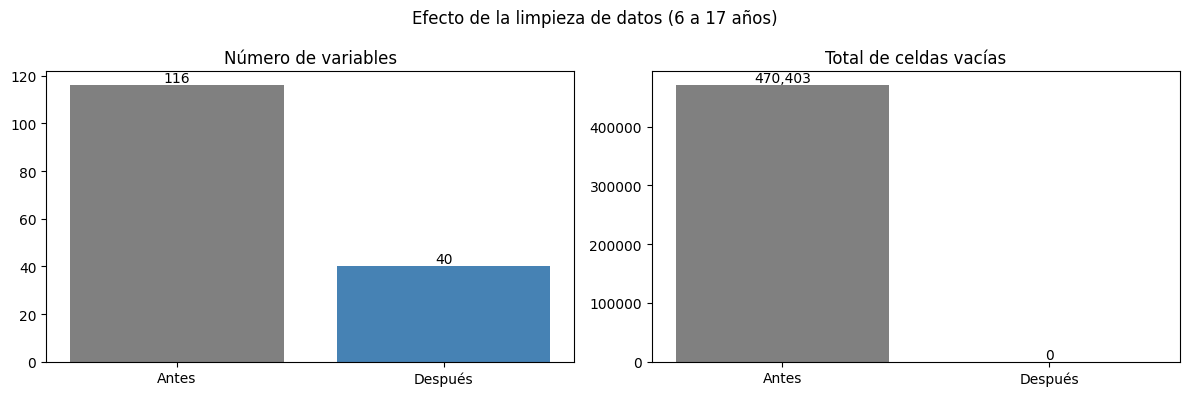

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Antes", "Después"], [df.shape[1], df_limpio.shape[1]], color=["gray", "steelblue"])
axes[0].set_title("Número de variables")
axes[1].bar(["Antes", "Después"], [df.isna().sum().sum(), df_limpio.isna().sum().sum()], color=["gray", "steelblue"])
axes[1].set_title("Total de celdas vacías")
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.suptitle("Efecto de la limpieza de datos (6 a 17 años)"); plt.tight_layout(); plt.show()

### Conclusión de la limpieza de datos

La limpieza redujo el conjunto de datos de **116 a 40 variables** y eliminó la
totalidad de las celdas vacías (de **470,403 a 0**), conservando los **14,350
registros** de la población de análisis (personas de 6 a 17 años).

Es importante señalar que esta reducción de vacíos **no se logró imputando
información de forma masiva**, sino identificando el origen de cada valor faltante:

- **Eliminación de variables:** la mayoría de los vacíos se encontraba en variables
  que no podían utilizarse: preguntas que no aplican a la población de estudio,
  variables redundantes y, sobre todo, variables cuya presencia revelaba la
  variable objetivo (fuga de información), como los apartados B y C del cuestionario.
- **Vacíos estructurales:** se identificaron cinco reglas del flujo del cuestionario
  que explican el 100% de los vacíos restantes en las variables conservadas. Estos
  se codificaron como la categoría "No aplica", ya que corresponden a preguntas que
  no se formularon y no a datos perdidos.
- **Imputación mínima:** únicamente 475 valores (respuestas "No sabe", "No especificado"
  o "No responde", menos del 1.2% de cada variable) se imputaron con la moda.

Además, se verificó que no existen registros duplicados ni inconsistencias en la
composición de los hogares. Los valores atípicos en el tamaño del hogar se conservaron
por corresponder a casos plausibles.

Como resultado, se obtuvo un conjunto de datos completo, con tipos de datos
correctamente asignados (numéricos, ordinales y categóricos), una variable objetivo
binaria (`NO_INSCRITO`) y sin variables que comprometan la validez de los análisis
posteriores.

## Extracción de características

La extracción de características consiste en **crear variables nuevas a partir de las existentes**, combinándolas o transformándolas para capturar un concepto que las variables originales expresan solo de forma parcial o dispersa.

El análisis exploratorio y la limpieza revelaron tres situaciones:

- **Información dispersa:** el equipamiento tecnológico del hogar está repartido en
  seis variables binarias (`P1_4_*`)
- **Variables redundantes:** el total de personas en la vivienda (`P1_1`) es
  exactamente la suma de hombres (`P1_2_1`) y mujeres (`P1_2_2`), por lo que las tres
  variables contienen información duplicada.
- **Conteos absolutos sin contexto:** el tamaño del hogar, por sí solo, no indica
  cuántos recursos tiene disponibles cada integrante.

A partir de esto, se construyeron las siguientes características:

| Variable nueva | Construcción | Concepto que captura |
|---|---|---|
| `EQUIPAMIENTO` | Número de equipos disponibles (`P1_4_*`) | Acceso tecnológico del hogar |
| `PERSONAS_POR_EQUIPO` | `P1_1` / (1 + `EQUIPAMIENTO`) | Disponibilidad de recursos por persona |
| `PROP_MUJERES` | `P1_2_2` / `P1_1` | Composición del hogar |
| `VALORACION_EDU` | Promedio invertido de `P4_1_*` | Valoración de la educación en el hogar |

  Trabajaremos en una copia para no modificar ni alterar el `df_limpio`

In [63]:
df_ext = df_limpio.copy()

### Extracción



Índice de equipamiento tecnológico

In [64]:
cols_equipo = ["P1_4_1", "P1_4_2", "P1_4_3", "P1_4_4", "P1_4_5", "P1_4_6"]
df_ext["EQUIPAMIENTO"] = (df_ext[cols_equipo] == "1").sum(axis=1)

Personas por dispositivo

In [65]:
df_ext["PERSONAS_POR_EQUIPO"] = df_ext["P1_1"] / (1 + df_ext["EQUIPAMIENTO"])

Proporción de mujeres en el hogar

In [66]:
df_ext["PROP_MUJERES"] = df_ext["P1_2_2"] / df_ext["P1_1"]

Valoración de la educación

In [67]:
df_ext["VALORACION_EDU"] = (5 - df_ext[["P4_1_1", "P4_1_2", "P4_1_3"]]).mean(axis=1)

In [68]:
nuevas = ["EQUIPAMIENTO", "PERSONAS_POR_EQUIPO", "PROP_MUJERES", "VALORACION_EDU"]
print(df_ext[nuevas].describe().round(2))
print(df_ext.groupby("NO_INSCRITO")[nuevas].mean().round(2))

       EQUIPAMIENTO  PERSONAS_POR_EQUIPO  PROP_MUJERES  VALORACION_EDU
count      14350.00             14350.00      14350.00        14350.00
mean           3.23                 1.48          0.52            3.59
std            1.45                 1.03          0.18            0.54
min            0.00                 0.29          0.00            1.00
25%            2.00                 0.83          0.40            3.33
50%            3.00                 1.25          0.50            3.67
75%            4.00                 1.75          0.67            4.00
max            6.00                14.00          1.00            4.00
             EQUIPAMIENTO  PERSONAS_POR_EQUIPO  PROP_MUJERES  VALORACION_EDU
NO_INSCRITO                                                                 
0                    3.30                 1.45          0.52            3.60
1                    2.35                 2.00          0.49            3.53


De las dos tablas presentadas, la segunda compara el promedio de cada característica nueva entre inscritos (0) y no inscritos (1).

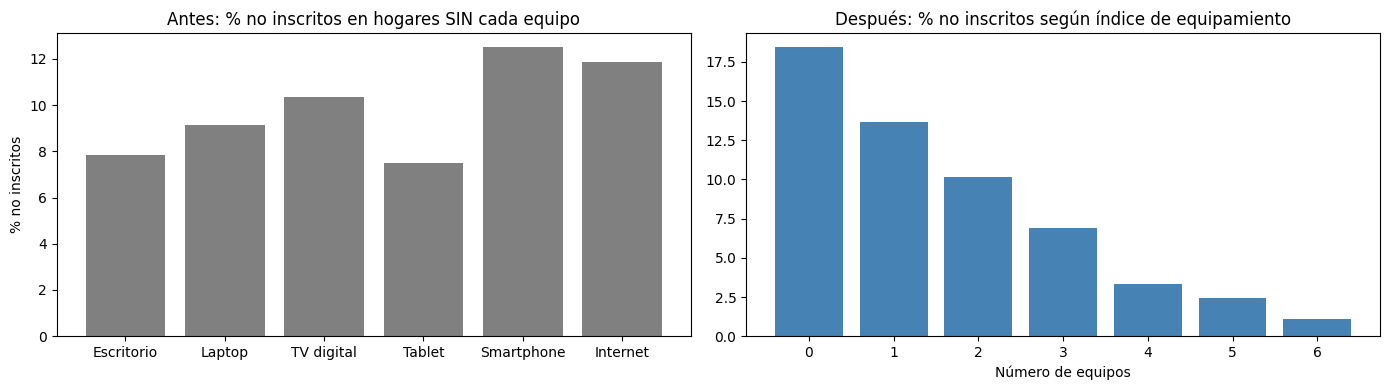

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
antes = {c: df_ext.loc[df_ext[c] == "2", "NO_INSCRITO"].mean() * 100 for c in cols_equipo}
etiquetas = ["Escritorio", "Laptop", "TV digital", "Tablet", "Smartphone", "Internet"]
axes[0].bar(etiquetas, antes.values(), color="gray")
axes[0].set_title("Antes: % no inscritos en hogares SIN cada equipo"); axes[0].set_ylabel("% no inscritos")
despues = df_ext.groupby("EQUIPAMIENTO")["NO_INSCRITO"].mean() * 100
axes[1].bar(despues.index, despues.values, color="steelblue")
axes[1].set_title("Después: % no inscritos según índice de equipamiento"); axes[1].set_xlabel("Número de equipos")
plt.tight_layout(); plt.show()

Al analizar cada equipo por separado (izquierda), la ausencia de cualquiera de ellos se asocia con una no inscripción de entre 7.5% y 12.5%, sin un patrón claro que indique cuál es más relevante.

Al combinarlos en un solo índice (derecha), aparece un **gradiente consistente**: la proporción de no inscritos disminuye conforme aumenta el número de equipos disponibles en el hogar, desde aproximadamente 18.5% en hogares sin ningún equipo hasta 1% en hogares con los seis.

Esto indica que la relación entre el equipamiento y la no inscripción es **acumulativa**: no depende de un equipo en particular, sino del nivel general de acceso tecnológico del hogar, que a su vez probablemente refleja su nivel socioeconómico. El índice resume seis variables en una sola, con una relación más clara e interpretable respecto a la variable objetivo.


In [71]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

excluir = ["FOLIO", "N_REN", "FACTOR", "NO_INSCRITO"]
X = df_ext.drop(columns=excluir)
y = df_ext["NO_INSCRITO"]
X = X.loc[:, X.nunique() > 1]          # quita columnas constantes (como P1_3, si lo es)

cat_cols = X.select_dtypes("category").columns
X[cat_cols] = X[cat_cols].apply(lambda s: s.cat.codes)

rng = np.random.default_rng(42)
X["RUIDO_ALEATORIO"] = rng.integers(0, 5, len(X))   # variable de referencia sin relación con y
print(X.shape)

(14350, 40)


In [72]:
continuas = ["PERSONAS_POR_EQUIPO", "PROP_MUJERES", "VALORACION_EDU"]
discretas = [c not in continuas for c in X.columns]
mi = pd.Series(mutual_info_classif(X, y, discrete_features=discretas, random_state=42),
               index=X.columns).sort_values(ascending=False)
umbral = mi["RUIDO_ALEATORIO"]
seleccionadas = mi[mi > umbral].index.drop("RUIDO_ALEATORIO", errors="ignore").tolist()
print(f"Umbral (ruido): {umbral:.4f} | Seleccionadas: {len(seleccionadas)} de {X.shape[1] - 1}")
print(mi.round(4).to_string())

Umbral (ruido): 0.0001 | Seleccionadas: 39 de 39
PA3_6                  0.0902
PA3_4                  0.0886
PA3_8_3                0.0886
PA3_8_8                0.0885
PA3_8_7                0.0883
PA3_8_2                0.0883
PA3_8_6                0.0883
PA3_8_4                0.0883
PA3_8_1                0.0883
PA3_8_5                0.0883
NIVEL_A                0.0801
GRADO_A                0.0760
PA3_2                  0.0718
PA3_1                  0.0714
PA3_7_1                0.0498
EDAD_NUM               0.0352
ESC                    0.0176
PERSONAS_POR_EQUIPO    0.0141
EQUIPAMIENTO           0.0140
P1_5                   0.0102
P1_4_6                 0.0089
P1_4_2                 0.0088
P1_4_1                 0.0052
P3_1                   0.0040
P1_4_3                 0.0032
ENT                    0.0028
P1_4_4                 0.0023
P1_1                   0.0022
P1_2_1                 0.0021
P1_2_2                 0.0021
VALORACION_EDU         0.0020
PA3_7_2              

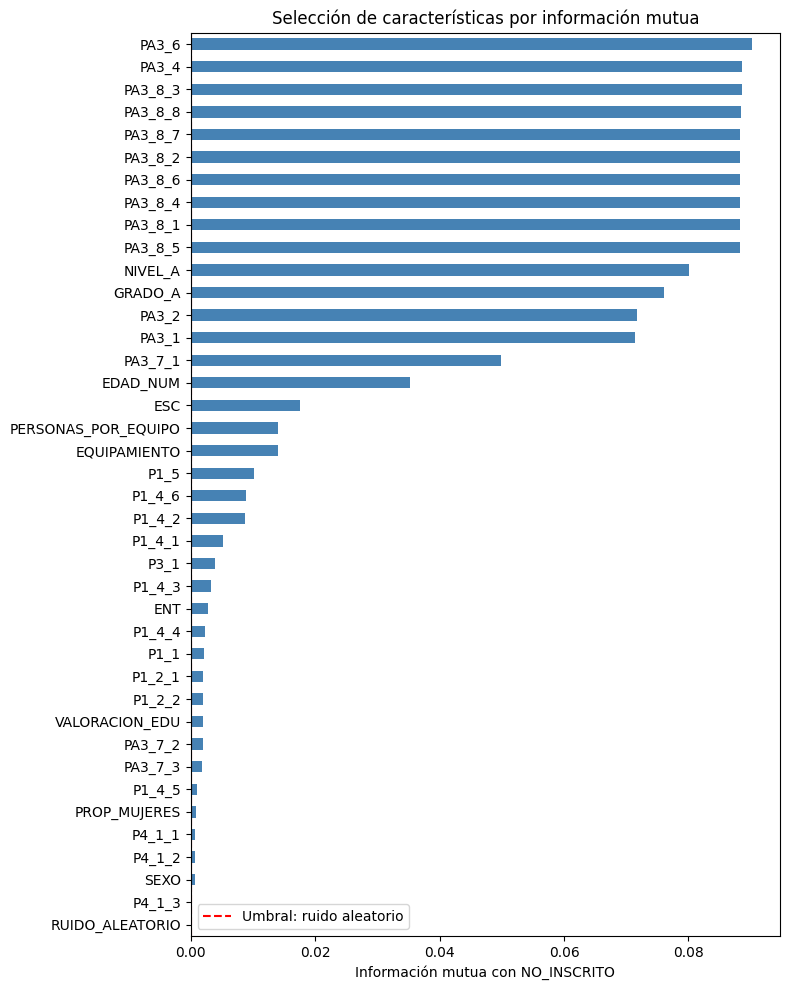

In [73]:
colores = ["steelblue" if c in seleccionadas else ("red" if c == "RUIDO_ALEATORIO" else "lightgray") for c in mi.index]
mi.plot(kind="barh", figsize=(8, 10), color=colores).invert_yaxis()
plt.axvline(umbral, color="red", linestyle="--", label="Umbral: ruido aleatorio")
plt.xlabel("Información mutua con NO_INSCRITO")
plt.title("Selección de características por información mutua")
plt.legend(); plt.tight_layout(); plt.show()

Al revisar los resultados identificamos dos problemas:
- Problema 1: el criterio del ruido no filtró nada. Se seleccionaron 39 de 39 variables. El umbral quedó en 0.0001, y hasta P4_1_3 (0.0001) lo supera por un margen mínimo
- Problema 2: la redundancia domina el ranking. Las primeras 10 variables (PA3_6 y las ocho PA3_8_*) tienen puntajes casi idénticos (0.0883 a 0.0902)

Por lo que ejecutaremos algunas correcciones para después volver a interpretar los datos.


In [74]:
X = X.drop(columns="RUIDO_ALEATORIO")
discretas = [c not in continuas for c in X.columns]

mi_real = pd.Series(mutual_info_classif(X, y, discrete_features=discretas, random_state=42), index=X.columns)
perm = pd.DataFrame([mutual_info_classif(X, y.sample(frac=1, random_state=i).values,
                                         discrete_features=discretas, random_state=42)
                     for i in range(20)], columns=X.columns)
umbral_var = perm.quantile(0.95)
relevantes = mi_real[mi_real > umbral_var].sort_values(ascending=False)
print(f"Relevantes: {len(relevantes)} de {X.shape[1]}")
print("Descartadas por irrelevantes:", mi_real.index.difference(relevantes.index).tolist())

Relevantes: 36 de 39
Descartadas por irrelevantes: ['P4_1_3', 'PROP_MUJERES', 'VALORACION_EDU']


Para identificar qué variables realmente aportan información, decidimos hacer una prueba en la que mezclamos aleatoriamente los valores de nuestra variable objetivo (y) 20 veces. En cada intento calculamos la información mutua entre las variables y la respuesta mezclada.

Con esto buscamos conocer qué tanta relación podría mostrar cada variable simplemente por casualidad. Además, este método nos ayuda a evitar que las variables con más categorías parezcan más importantes solo por tener una mayor cantidad de valores posibles.

Finalmente, conservamos únicamente aquellas variables cuyo resultado real fue mayor que el percentil 95 de los resultados obtenidos al azar. De esta manera, buscamos quedarnos con las variables que muestran una relación más clara con lo que queremos predecir.

In [75]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    tabla = pd.crosstab(a, b)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    return np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))

Xd = X.copy()
for c in continuas:
    Xd[c] = pd.qcut(Xd[c].rank(method="first"), 5, labels=False)   # discretiza para comparar

finales, redundantes_sel = [], {}
for c in relevantes.index:
    asociadas = [f for f in finales if cramers_v(Xd[c], Xd[f]) >= 0.8]
    if asociadas:
        redundantes_sel[c] = asociadas[0]
    else:
        finales.append(c)

print(f"Seleccionadas finales: {len(finales)}")
print(finales)
print("Redundantes (variable → con cuál):", redundantes_sel)

Seleccionadas finales: 33
['PA3_6', 'PA3_4', 'PA3_8_3', 'PA3_8_8', 'PA3_8_7', 'PA3_8_2', 'PA3_8_6', 'PA3_8_4', 'PA3_8_1', 'PA3_8_5', 'NIVEL_A', 'GRADO_A', 'PA3_2', 'PA3_7_1', 'EDAD_NUM', 'PERSONAS_POR_EQUIPO', 'EQUIPAMIENTO', 'P1_5', 'P1_4_2', 'P1_4_1', 'P3_1', 'P1_4_3', 'ENT', 'P1_4_4', 'P1_1', 'P1_2_1', 'P1_2_2', 'PA3_7_2', 'PA3_7_3', 'P1_4_5', 'P4_1_1', 'P4_1_2', 'SEXO']
Redundantes (variable → con cuál): {'PA3_1': 'PA3_6', 'ESC': 'NIVEL_A', 'P1_4_6': 'EQUIPAMIENTO'}


Para evitar quedarnos con variables que aportan información muy parecida, utilizamos la V de Cramér, una medida que nos permite conocer qué tan relacionadas están dos variables categóricas. Su valor va de 0 a 1, donde 0 significa que no hay asociación y 1 indica que existe una asociación perfecta.

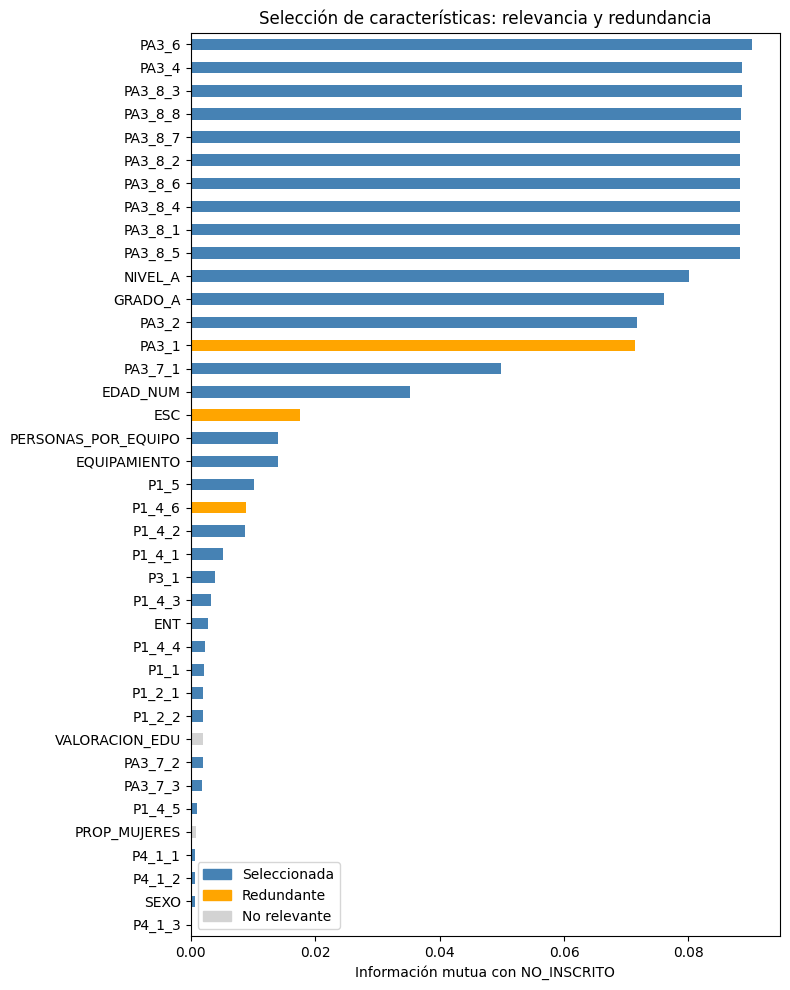

In [76]:
colores = ["steelblue" if c in finales else ("orange" if c in redundantes_sel else "lightgray")
           for c in mi_real.sort_values(ascending=False).index]
mi_real.sort_values(ascending=False).plot(kind="barh", figsize=(8, 10), color=colores).invert_yaxis()
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color="steelblue", label="Seleccionada"),
                    Patch(color="orange", label="Redundante"),
                    Patch(color="lightgray", label="No relevante")])
plt.xlabel("Información mutua con NO_INSCRITO")
plt.title("Selección de características: relevancia y redundancia")
plt.tight_layout(); plt.show()

Observamos que el resultado sigue sin ser el indicado, por lo que se recurre a una tercer corrección.

In [77]:
raices = ["PA3_1", "PA3_4"]   # variables que definen la estructura del cuestionario
evaluar = [c for c in finales if (df_ext[c].astype(str) == "No aplica").any()]

resultado = {}
for c in evaluar:
    m = (df_ext[c].astype(str) != "No aplica").values
    xc, yc = X.loc[m, [c]], y[m]
    real = mutual_info_classif(xc, yc, discrete_features=True, random_state=42)[0]
    azar = [mutual_info_classif(xc, yc.sample(frac=1, random_state=i).values,
                                discrete_features=True, random_state=42)[0] for i in range(20)]
    umbral = np.quantile(azar, 0.95)
    resultado[c] = {"MI propia": round(real, 4), "umbral azar": round(umbral, 4), "relevante": real > umbral}

tabla_propia = pd.DataFrame(resultado).T
print(tabla_propia)

        MI propia umbral azar relevante
PA3_6      0.0021      0.0002      True
PA3_4      0.0181      0.0001      True
PA3_8_3    0.0003      0.0002      True
PA3_8_8    0.0002         0.0      True
PA3_8_7       0.0      0.0001     False
PA3_8_2       0.0      0.0001     False
PA3_8_6       0.0      0.0001     False
PA3_8_4       0.0      0.0002     False
PA3_8_1       0.0      0.0002     False
PA3_8_5       0.0      0.0001     False
NIVEL_A    0.0091      0.0004      True
GRADO_A    0.0049      0.0004      True
PA3_2      0.0004      0.0002      True
PA3_7_1       0.0      0.0001     False
P1_5       0.0043      0.0017      True
PA3_7_2    0.0018      0.0003      True
PA3_7_3    0.0014      0.0003      True


In [78]:
sin_propia = [c for c in evaluar if not tabla_propia.loc[c, "relevante"] and c not in raices]
finales_v2 = [c for c in finales if c not in sin_propia]
for r in raices:
    if r not in finales_v2:
        finales_v2.append(r)

print(f"Selección final: {len(finales_v2)} variables")
print("Eliminadas por relevancia solo estructural:", sin_propia)
print(finales_v2)

Selección final: 27 variables
Eliminadas por relevancia solo estructural: ['PA3_8_7', 'PA3_8_2', 'PA3_8_6', 'PA3_8_4', 'PA3_8_1', 'PA3_8_5', 'PA3_7_1']
['PA3_6', 'PA3_4', 'PA3_8_3', 'PA3_8_8', 'NIVEL_A', 'GRADO_A', 'PA3_2', 'EDAD_NUM', 'PERSONAS_POR_EQUIPO', 'EQUIPAMIENTO', 'P1_5', 'P1_4_2', 'P1_4_1', 'P3_1', 'P1_4_3', 'ENT', 'P1_4_4', 'P1_1', 'P1_2_1', 'P1_2_2', 'PA3_7_2', 'PA3_7_3', 'P1_4_5', 'P4_1_1', 'P4_1_2', 'SEXO', 'PA3_1']


In [79]:
dependencia = ["P1_2_1", "P1_2_2"]
seleccion_final = [c for c in finales_v2 if c not in dependencia]
print(f"Selección final: {len(seleccion_final)} variables")
print(seleccion_final)

Selección final: 25 variables
['PA3_6', 'PA3_4', 'PA3_8_3', 'PA3_8_8', 'NIVEL_A', 'GRADO_A', 'PA3_2', 'EDAD_NUM', 'PERSONAS_POR_EQUIPO', 'EQUIPAMIENTO', 'P1_5', 'P1_4_2', 'P1_4_1', 'P3_1', 'P1_4_3', 'ENT', 'P1_4_4', 'P1_1', 'PA3_7_2', 'PA3_7_3', 'P1_4_5', 'P4_1_1', 'P4_1_2', 'SEXO', 'PA3_1']


Al revisar los resultados, encontramos que algunas variables tienen una mayor relación con la inscripción escolar que otras:

PA3_4 fue la variable con mayor relevancia (0.0181). Esto nos indica que haber concluido o no el grado escolar anterior puede ayudarnos a predecir si una persona continúa inscrita.

NIVEL_A (0.0091), GRADO_A (0.0049) y P1_5 (0.0043) también mostraron resultados relevantes, por lo que consideramos que pueden aportar información útil para nuestro modelo.

En el caso de PA3_7_2 y PA3_7_3, encontramos que presentar exámenes extraordinarios o tener que recursar materias también aporta información.

Finalmente, encontramos dos variables con una relevancia muy pequeña: PA3_8_3 (0.0003) y PA3_8_8 (0.0002).

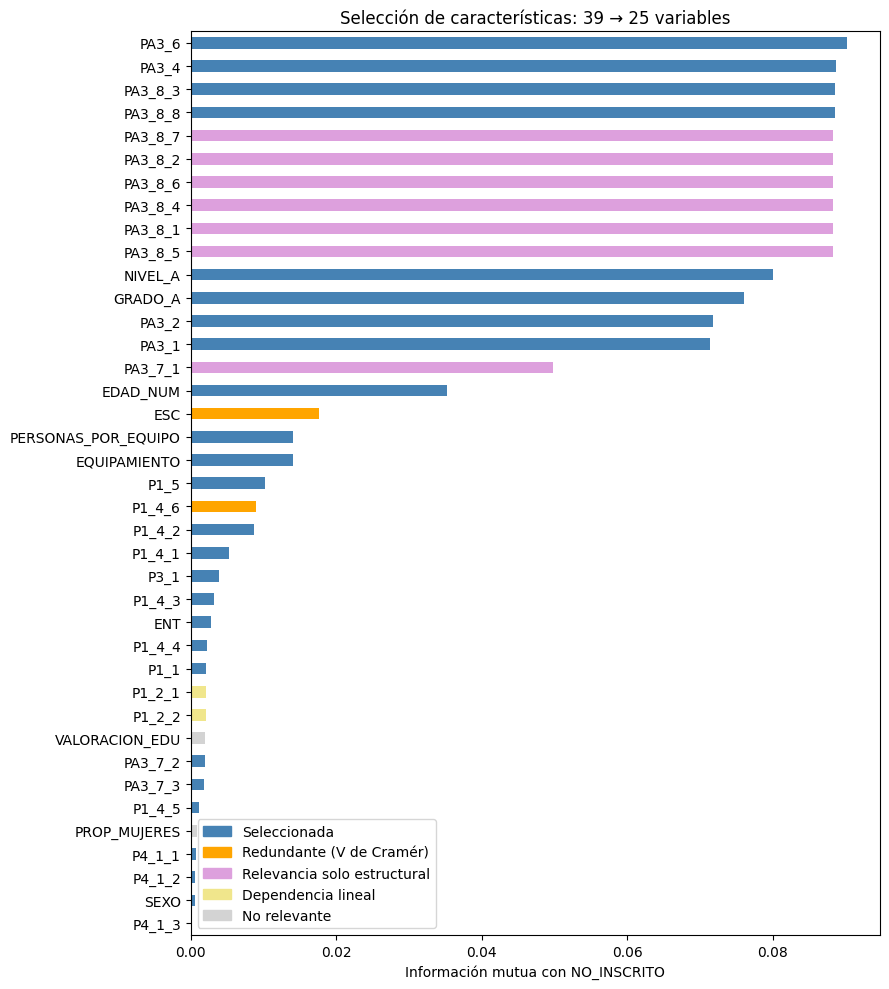

In [80]:
motivo = {}
for c in mi_real.index:
    if c in seleccion_final: motivo[c] = "Seleccionada"
    elif c in dependencia: motivo[c] = "Dependencia lineal"
    elif c in sin_propia: motivo[c] = "Relevancia solo estructural"
    elif c in redundantes_sel: motivo[c] = "Redundante (V de Cramér)"
    else: motivo[c] = "No relevante"

paleta = {"Seleccionada": "steelblue", "Redundante (V de Cramér)": "orange",
          "Relevancia solo estructural": "plum", "Dependencia lineal": "khaki", "No relevante": "lightgray"}
orden = mi_real.sort_values(ascending=False)
orden.plot(kind="barh", figsize=(9, 10), color=[paleta[motivo[c]] for c in orden.index]).invert_yaxis()
plt.legend(handles=[Patch(color=v, label=k) for k, v in paleta.items()])
plt.xlabel("Información mutua con NO_INSCRITO")
plt.title(f"Selección de características: {len(orden)} → {len(seleccion_final)} variables")
plt.tight_layout(); plt.show()

La longitud de las barras corresponde a la información
mutua calculada con todas las categorías, incluida "No aplica". Por ello, algunas variables del apartado A (como `PA3_8_3` y `PA3_8_8`) aparecen con valores altos aunque su relevancia propia, evaluada sin esa categoría, es mínima (ver tabla de relevancia propia). `PA3_1` se muestra como seleccionada porque se reincorporó como variable estructural, a pesar de que la prueba de redundancia la había descartado.

## Reducción de dimensionalidad (PCA)

La reducción de dimensionalidad transforma las variables originales en un número menor de variables nuevas (componentes) que conservan la mayor parte de la información.

In [81]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_sel = df_ext[seleccion_final].copy()
X_oh = pd.get_dummies(X_sel, drop_first=True, dtype=int)
X_esc = StandardScaler().fit_transform(X_oh)
print("Variables seleccionadas:", X_sel.shape[1], "→ tras codificación one-hot:", X_oh.shape[1])

Variables seleccionadas: 25 → tras codificación one-hot: 90


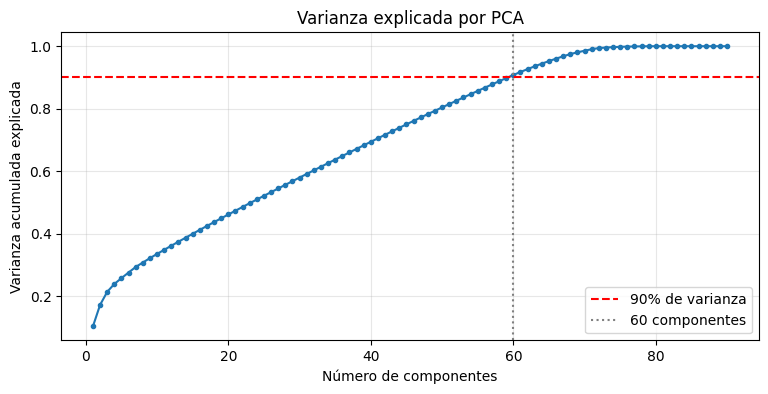

Se necesitan 60 componentes para explicar el 90% de la varianza (de 90 dimensiones)


In [82]:
pca_full = PCA().fit(X_esc)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k = int(np.argmax(var_acum >= 0.90) + 1)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker=".")
plt.axhline(0.90, color="red", linestyle="--", label="90% de varianza")
plt.axvline(k, color="gray", linestyle=":", label=f"{k} componentes")
plt.xlabel("Número de componentes"); plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza explicada por PCA"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(f"Se necesitan {k} componentes para explicar el 90% de la varianza (de {X_oh.shape[1]} dimensiones)")

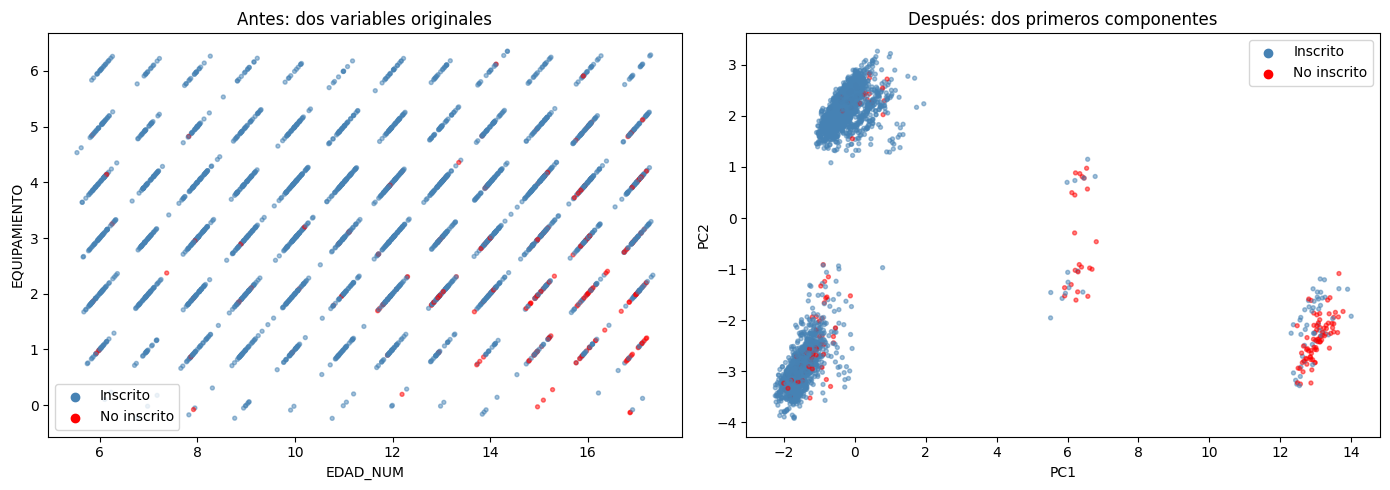

In [83]:
pca = PCA(n_components=k, random_state=42)
X_pca = pca.fit_transform(X_esc)

muestra = df_ext.sample(3000, random_state=42).index
pos = df_ext.index.get_indexer(muestra)
color = y.loc[muestra].map({0: "steelblue", 1: "red"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
jit = lambda s: s + np.random.default_rng(0).normal(0, 0.15, len(s))
axes[0].scatter(jit(df_ext.loc[muestra, "EDAD_NUM"]), jit(df_ext.loc[muestra, "EQUIPAMIENTO"]), c=color, s=8, alpha=.5)
axes[0].set(xlabel="EDAD_NUM", ylabel="EQUIPAMIENTO", title="Antes: dos variables originales")
axes[1].scatter(X_pca[pos, 0], X_pca[pos, 1], c=color, s=8, alpha=.5)
axes[1].set(xlabel="PC1", ylabel="PC2", title="Después: dos primeros componentes")
for ax in axes:
    ax.scatter([], [], c="steelblue", label="Inscrito"); ax.scatter([], [], c="red", label="No inscrito"); ax.legend()
plt.tight_layout(); plt.show()

In [84]:
cargas = pd.DataFrame(pca.components_[:2].T, index=X_oh.columns, columns=["PC1", "PC2"])
for pc in ["PC1", "PC2"]:
    print(f"\n{pc} ({pca.explained_variance_ratio_[int(pc[-1]) - 1]:.1%} de la varianza) — variables con más peso:")
    print(cargas[pc].abs().sort_values(ascending=False).head(6).round(3))


PC1 (10.5% de la varianza) — variables con más peso:
PA3_8_8_No aplica    0.308
PA3_6_No aplica      0.308
PA3_8_3_No aplica    0.308
PA3_4_No aplica      0.306
NIVEL_A_No aplica    0.306
GRADO_A_No aplica    0.306
Name: PC1, dtype: float64

PC2 (6.8% de la varianza) — variables con más peso:
PA3_7_3_No aplica    0.366
PA3_7_2_No aplica    0.366
PA3_7_3_2            0.361
PA3_7_2_2            0.351
NIVEL_A_03           0.350
EDAD_NUM             0.329
Name: PC2, dtype: float64


Se aplicó **Análisis de Componentes Principales (PCA)**. Aunque la selección redujo el conjunto a 25 variables, la mayoría son categóricas, y para utilizarlas en métodos numéricos deben codificarse con variables indicadoras (one-hot), lo que multiplica el número de dimensiones. PCA permite condensar esas dimensiones en un número reducido de componentes, eliminando la redundancia que aún existe entre variables relacionadas, por ejemplo, el nivel y el grado escolar, o el equipamiento y sus componentes individuales.

## Aumento de datos (SMOTE)

El aumento de datos genera nuevas observaciones sintéticas a partir de las existentes. En datos tabulares se utiliza principalmente para corregir el **desbalance de clases**,
que ocurre cuando una categoría de la variable objetivo está mucho menos representada que la otra.

In [85]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_tr, X_te, y_tr, y_te = train_test_split(X_pca, y.values, test_size=0.2,
                                          stratify=y.values, random_state=42)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

print("Entrenamiento antes  →", dict(zip(["inscritos", "no inscritos"], np.bincount(y_tr))))
print("Entrenamiento después →", dict(zip(["inscritos", "no inscritos"], np.bincount(y_res))))
print("Prueba (sin cambios)  →", dict(zip(["inscritos", "no inscritos"], np.bincount(y_te))))
print("Observaciones sintéticas generadas:", len(X_res) - len(X_tr))

Entrenamiento antes  → {'inscritos': np.int64(10717), 'no inscritos': np.int64(763)}
Entrenamiento después → {'inscritos': np.int64(10717), 'no inscritos': np.int64(10717)}
Prueba (sin cambios)  → {'inscritos': np.int64(2679), 'no inscritos': np.int64(191)}
Observaciones sintéticas generadas: 9954


Se generaron 9,954 observaciones sintéticas, unas 13 veces el número de no inscritos reales.

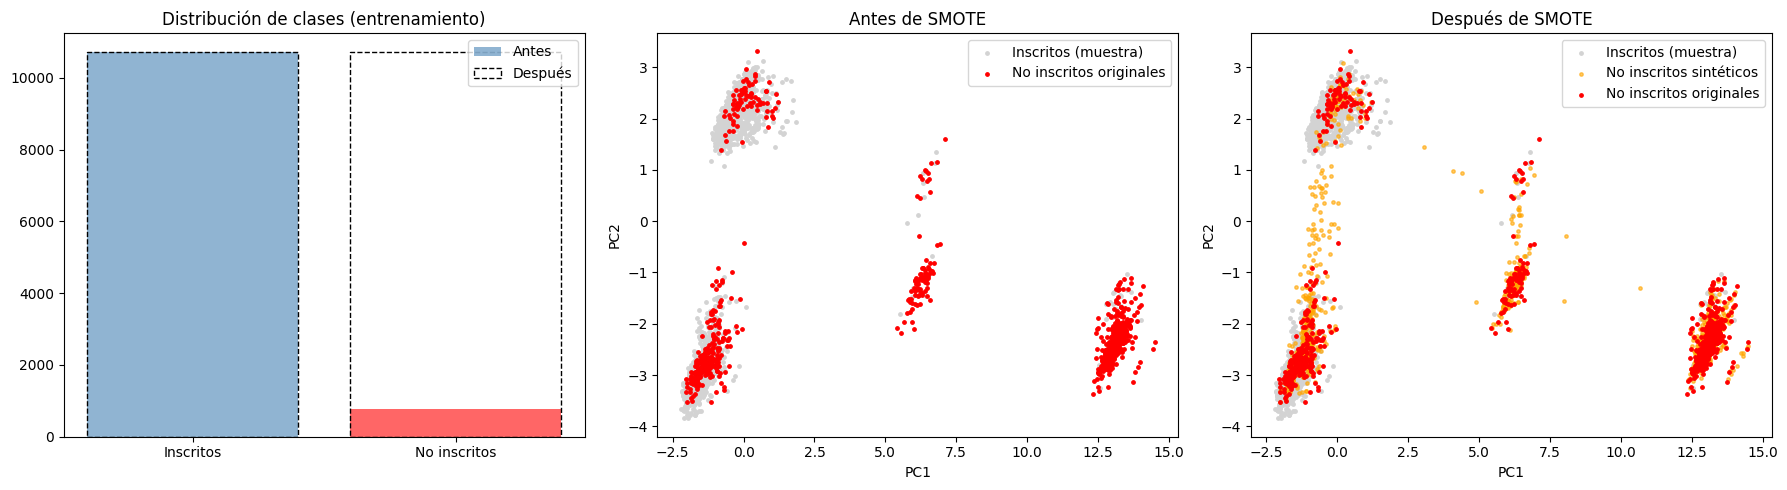

In [86]:
n = len(X_tr)
sint = X_res[n:]                       # SMOTE agrega los sintéticos al final
rng = np.random.default_rng(0)
idx_ins = rng.choice(np.where(y_tr == 0)[0], 2000, replace=False)
idx_sint = rng.choice(len(sint), min(1500, len(sint)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(["Inscritos", "No inscritos"], np.bincount(y_tr), color=["steelblue", "red"], alpha=.6, label="Antes")
axes[0].bar(["Inscritos", "No inscritos"], np.bincount(y_res), color="none", edgecolor="black", linestyle="--", label="Después")
axes[0].set_title("Distribución de clases (entrenamiento)"); axes[0].legend()

for ax, titulo, con_sint in [(axes[1], "Antes de SMOTE", False), (axes[2], "Después de SMOTE", True)]:
    ax.scatter(X_tr[idx_ins, 0], X_tr[idx_ins, 1], c="lightgray", s=6, label="Inscritos (muestra)")
    if con_sint:
        ax.scatter(sint[idx_sint, 0], sint[idx_sint, 1], c="orange", s=6, alpha=.6, label="No inscritos sintéticos")
    ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], c="red", s=6, label="No inscritos originales")
    ax.set(xlabel="PC1", ylabel="PC2", title=titulo); ax.legend()
plt.tight_layout(); plt.show()

Observamos que la gráfica tiene tres paneles:

- Barras: el conteo de cada clase antes (color) y después (contorno punteado).
- Antes: los no inscritos originales (rojo) sobre los inscritos (gris).
- Después: los mismos puntos, más los sintéticos (naranja). Observamos que caen dentro de la región roja y no es una dispersión al azar.
- Algunos datos sintéticos caen entre los grupos.

Para corregir el desbalance entre las clases, utilizamos SMOTE únicamente sobre el conjunto de entrenamiento. Al inicio teníamos 10,717 personas inscritas y solamente 763 no inscritas, lo que representaba una distribución de 93.4% y 6.6%, respectivamente.

Con SMOTE se generaron 9,954 observaciones sintéticas de la clase minoritaria, logrando que el conjunto de entrenamiento quedara equilibrado con 10,717 casos de cada clase.

En cambio, el conjunto de prueba se dejó sin modificaciones, manteniendo su distribución original de 2,679 personas inscritas y 191 no inscritas. Esto lo hicimos para evaluar el modelo en condiciones más cercanas a los datos reales y evitar que el balance artificial afectara la evaluación de su desempeño.

La mayoría de los datos sintéticos generados por SMOTE quedaron cerca de las observaciones reales de las personas no inscritas. Esto indica que, en general, el método ayudó a reforzar la representación de la clase minoritaria en zonas donde ya existían casos similares.

Sin embargo, también encontramos algunos puntos sintéticos ubicados entre distintos grupos, en regiones donde originalmente no había observaciones reales.

## Conclusiones

Se aplicaron las cinco técnicas de procesamiento a los microdatos de la ENAPE 2021 del INEGI, con el objetivo de preparar los datos para analizar qué características de
la persona, su hogar y su trayectoria escolar previa se asocian con no estar inscrita en el ciclo escolar 2021-2022.

| Técnica | Método | Antes → Después | Hallazgo principal |
|---|---|---|---|
| Limpieza | Eliminación de variables, reglas de flujo, imputación por moda | 116 → 40 variables; 470,403 → 0 vacíos | El 100% de los vacíos restantes se explicó por 5 reglas del cuestionario |
| Extracción | Índices y razones construidos manualmente | +4 variables | El índice de equipamiento muestra un gradiente claro: de 18.5% a 1% de no inscripción |
| Selección | Información mutua con permutación, V de Cramér y relevancia propia | 39 → 25 variables | Varias variables debían su relevancia solo a la categoría "No aplica" |
| Reducción | PCA (90% de varianza) | [D] → [k] dimensiones | Los datos forman grupos asociados a la trayectoria escolar previa |
| Aumento | SMOTE (solo entrenamiento) | 763 → 10,717 no inscritos | Balance logrado, con puntos sintéticos fuera de las regiones reales |

## Declaración de uso de inteligencia artificial

En la elaboración de esta práctica se utilizó **Claude (Anthropic)** como herramienta de apoyo. A continuación se describe su uso:

**Usos de la herramienta:**

- **Repaso conceptual:** explicación de las técnicas de procesamiento vistas en clase
  (limpieza, aumento, extracción, selección y reducción de dimensionalidad).
- **Búsqueda y evaluación del dataset:** apoyo para verificar si los conjuntos de datos
  considerados eran reales o sintéticos, y sugerencia de fuentes con datos reales
  sobre educación en México, entre ellas la ENAPE 2021 del INEGI.
- **Código:** propuesta de fragmentos de código en Python (pandas, scikit-learn,
  imbalanced-learn, matplotlib) para el análisis exploratorio y cada una de las técnicas.
- **Depuración:** diagnóstico y corrección de errores durante la ejecución del notebook que fueron necesarios para obtener un resultado favorable para la aplicación de algunas técnicas.

**Trabajo propio:**

- Descarga, carga y ejecución de todo el código en el notebook, así como la revisión de
  cada salida antes de continuar con el siguiente paso.
- Toma de decisiones a lo largo del análisis como lo fue la elección del dataset, la variable objetivo y el rango de edad.
- Verificación de que los textos coincidieran con los resultados obtenidos

Considero que la IA funcionó como una guía y apoyo para entender el proceso, y que puedo explicar cada paso y decisión del trabajo.